In [1]:
# 01_lightgbm_baseline
#
# 목적: 2017-01-31까지 관측된 피처로 LightGBM 이진분류 베이스라인을 학습한다.
#      - split 컬럼(train/valid/test)을 그대로 사용 (msno stratified 70/15/15)
#      - 사전에 정의된 범주형 코드(city, registered_via, gender)는 LightGBM category dtype으로 처리
#      - 학습은 실제 클래스 분포를 유지하고 valid에서 F1-최적 threshold를 선택
#      - 불균형 데이터이므로 ROC-AUC, PR-AUC, Recall, F1을 함께 확인
#      - valid로 early stopping하며 이 단계에서는 test를 평가하지 않음
#
# 입력: data/processed/model_table_final.csv
# 출력: models/lightgbm_baseline_20170131.txt, models/lightgbm_baseline_20170131_meta.json

In [2]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from sklearn.metrics import roc_auc_score, log_loss, precision_recall_fscore_support, confusion_matrix

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})
SERIES_1 = "#2a78d6"

CATEGORICAL_COLS = ["city", "registered_via", "gender"]
DROP_COLS = ["msno", "snapshot", "split", "is_churn"]

In [3]:
df = pd.read_csv(PROCESSED_DIR / "model_table_final.csv")

# 학습 전에 최종 전처리 결과와 시간 누수 방지 조건을 다시 검증
assert df["snapshot"].eq("2017-01-31").all(), "snapshot 기준일이 2017-01-31이 아닙니다."
assert df.isna().sum().sum() == 0, "최종 테이블에 결측치가 있습니다."
assert df["msno"].duplicated().sum() == 0, "사용자 중복이 있습니다."
assert (df["days_since_last_txn"] < 0).sum() == 0, "관측 종료일 이후 거래가 포함됐습니다."

for c in CATEGORICAL_COLS:
    df[c] = df[c].astype("category")

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
print(f"피처 수: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

train_df = df[df["split"] == "train"]
valid_df = df[df["split"] == "valid"]
test_df = df[df["split"] == "test"]
print(f"train {len(train_df):,} / valid {len(valid_df):,} / test {len(test_df):,}")
print("모델 입력 검증 완료")

피처 수: 40
['city', 'registered_via', 'bd_clean', 'bd_is_missing', 'gender', 'tenure_days', 'txn_count', 'payment_method_nunique', 'plan_days_nunique', 'auto_renew_rate', 'cancel_count', 'cancel_rate', 'total_amount_paid', 'avg_discount', 'last_payment_plan_days', 'last_plan_list_price', 'last_actual_amount_paid', 'last_is_auto_renew', 'days_since_last_txn', 'days_to_expire', 'd7_active_days', 'd7_avg_num_unq', 'd7_avg_total_secs', 'd7_completion_rate', 'd30_active_days', 'd30_avg_num_unq', 'd30_avg_total_secs', 'd30_completion_rate', 'd90_active_days', 'd90_avg_num_unq', 'd90_avg_total_secs', 'd90_completion_rate', 'full_active_days', 'full_avg_num_unq', 'full_avg_total_secs', 'full_completion_rate', 'trend_secs_recent15_vs_prior15', 'has_member_record', 'has_transaction_record', 'has_log_activity']
train 695,051 / valid 148,940 / test 148,940
모델 입력 검증 완료


In [4]:
X_train, y_train = train_df[FEATURE_COLS], train_df["is_churn"]
X_valid, y_valid = valid_df[FEATURE_COLS], valid_df["is_churn"]

train_set = lgb.Dataset(X_train, label=y_train, categorical_feature=CATEGORICAL_COLS)
valid_set = lgb.Dataset(X_valid, label=y_valid, categorical_feature=CATEGORICAL_COLS, reference=train_set)

params = {
    "objective": "binary",
    "metric": ["auc", "binary_logloss"],
    "num_leaves": 31,
    "learning_rate": 0.05,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "seed": 42,
    "verbose": -1,
}
# 베이스라인은 클래스 가중치 없이 실제 분포로 학습한다.
# 분류 threshold는 valid에서 F1 기준으로 선택하고, 확률 순위 성능은 ROC-AUC와 PR-AUC로 평가한다.
# first_metric_only=True로 "auc" 기준 하나만으로 best iteration을 명확히 정한다.

model = lgb.train(
    params,
    train_set,
    num_boost_round=2000,
    valid_sets=[train_set, valid_set],
    valid_names=["train", "valid"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, first_metric_only=True),
        lgb.log_evaluation(period=50),
    ],
)

print(f"best iteration: {model.best_iteration}")

Training until validation scores don't improve for 100 rounds
[50]	train's auc: 0.891538	train's binary_logloss: 0.150962	valid's auc: 0.893977	valid's binary_logloss: 0.150457
[100]	train's auc: 0.895478	train's binary_logloss: 0.147171	valid's auc: 0.896118	valid's binary_logloss: 0.147236
[150]	train's auc: 0.899274	train's binary_logloss: 0.145241	valid's auc: 0.897413	valid's binary_logloss: 0.146318
[200]	train's auc: 0.902251	train's binary_logloss: 0.14391	valid's auc: 0.897624	valid's binary_logloss: 0.146062
[250]	train's auc: 0.905186	train's binary_logloss: 0.142696	valid's auc: 0.897743	valid's binary_logloss: 0.145918
[300]	train's auc: 0.907652	train's binary_logloss: 0.141564	valid's auc: 0.897895	valid's binary_logloss: 0.145818
[350]	train's auc: 0.909763	train's binary_logloss: 0.14055	valid's auc: 0.897856	valid's binary_logloss: 0.145798
[400]	train's auc: 0.911643	train's binary_logloss: 0.139586	valid's auc: 0.897911	valid's binary_logloss: 0.145798
[450]	train's

In [5]:
from sklearn.metrics import precision_recall_curve, average_precision_score

valid_pred = model.predict(X_valid, num_iteration=model.best_iteration)

auc = roc_auc_score(y_valid, valid_pred)
logloss = log_loss(y_valid, valid_pred)
pr_auc = average_precision_score(y_valid, valid_pred)

# 불균형 데이터라 고정 0.5 threshold 대신, valid에서 F1이 최대가 되는 threshold를 찾아서 사용
precisions, recalls, thresholds = precision_recall_curve(y_valid, valid_pred)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)
best_idx = f1_scores[:-1].argmax()
best_threshold = thresholds[best_idx]

valid_pred_label = (valid_pred >= best_threshold).astype(int)
precision, recall, f1, _ = precision_recall_fscore_support(y_valid, valid_pred_label, average="binary")

random_pr_auc = y_valid.mean()

print(f"[valid] AUC: {auc:.4f}  PR-AUC: {pr_auc:.4f}  LogLoss: {logloss:.4f}")
print(f"[valid] 무작위 PR-AUC 기준선(이탈률): {random_pr_auc:.4f}")
print(f"[valid] 최적 threshold(F1 기준): {best_threshold:.4f}")
print(f"[valid] Precision: {precision:.4f}  Recall: {recall:.4f}  F1: {f1:.4f}")
print()
cm = confusion_matrix(y_valid, valid_pred_label)
print("Confusion matrix (rows=actual, cols=predicted):")
print(cm)

[valid] AUC: 0.8981  PR-AUC: 0.5726  LogLoss: 0.1457
[valid] 무작위 PR-AUC 기준선(이탈률): 0.0639
[valid] 최적 threshold(F1 기준): 0.3018
[valid] Precision: 0.5537  Recall: 0.5427  F1: 0.5482

Confusion matrix (rows=actual, cols=predicted):
[[135255   4164]
 [  4354   5167]]


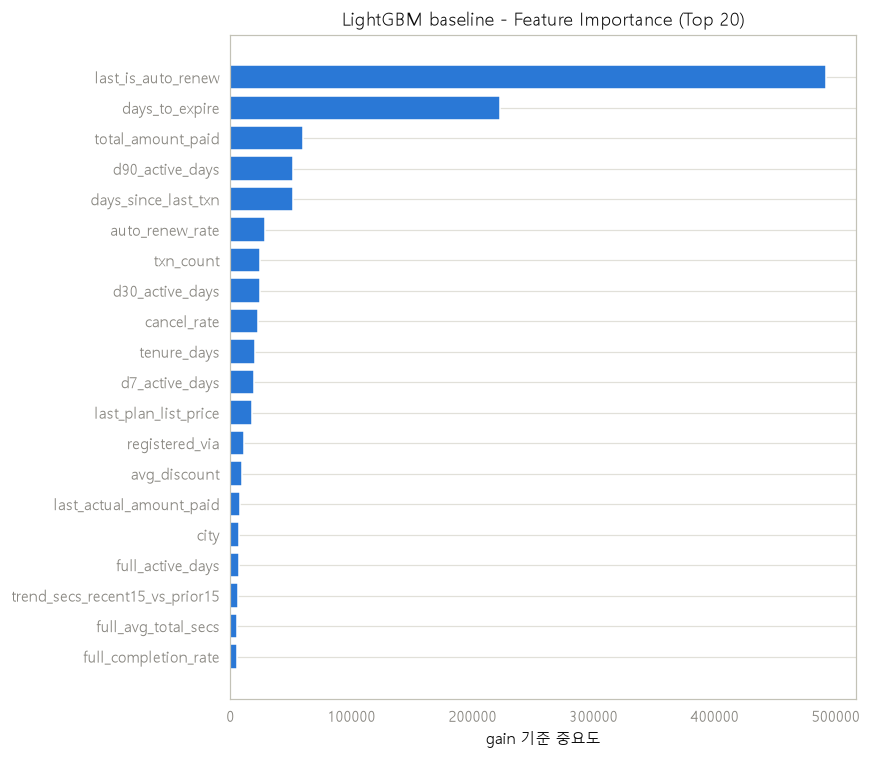

In [6]:
importance = pd.Series(model.feature_importance(importance_type="gain"), index=FEATURE_COLS)
importance = importance.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(importance.index, importance.values, color=SERIES_1)
ax.set_xlabel("gain 기준 중요도")
ax.set_title("LightGBM baseline - Feature Importance (Top 20)")
ax.grid(axis="x")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [8]:
importance.sort_values(
    ascending=False
).head(15).to_frame("gain_importance")

,gain_importance
last_is_auto_renew,492093.745589
days_to_expire,222349.817955
total_amount_paid,59823.678417
d90_active_days,52049.455266
days_since_last_txn,51925.641288
auto_renew_rate,28786.857438
txn_count,24757.869385
d30_active_days,24453.364058
cancel_rate,22857.305345
tenure_days,20317.809929


In [7]:
MODEL_PATH = MODELS_DIR / "lightgbm_baseline_20170131.txt"
META_PATH = MODELS_DIR / "lightgbm_baseline_20170131_meta.json"

model.save_model(str(MODEL_PATH))
metadata = {
    "feature_cutoff": "2017-01-31",
    "best_iteration": int(model.best_iteration),
    "best_threshold_f1": float(best_threshold),
    "valid_auc": float(auc),
    "valid_pr_auc": float(pr_auc),
    "valid_logloss": float(logloss),
    "feature_cols": FEATURE_COLS,
    "categorical_cols": CATEGORICAL_COLS,
}
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"모델 저장 완료: {MODEL_PATH}")
print(f"메타데이터 저장 완료: {META_PATH}")

모델 저장 완료: ..\models\lightgbm_baseline_20170131.txt
메타데이터 저장 완료: ..\models\lightgbm_baseline_20170131_meta.json
